<a href="https://colab.research.google.com/github/rperera729/AI-Driven-UHI-Mapping-UK/blob/main/UHI_Mapping_Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import sys
import torch

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Extract patches to local high-speed disk
!rm -rf /content/local_patches
!mkdir -p /content/local_patches
!unzip -q /content/drive/MyDrive/UHI_Project/patches.zip -d /content/local_patches

# 3. Reconstruct your explicit URL safely using string pieces
domain = "https://github.com"
username = "rperera729"
repo_name = "AI-Driven-UHI-Mapping-UK"
full_url = f"{domain}/{username}/{repo_name}.git"

%cd /content
!rm -rf /content/AI-Driven-UHI-Mapping-UK
print(f"Downloading files from explicit repository address: {full_url}")
!git clone {full_url}

# Force notebook runtime focus inside the newly created project repository
%cd /content/AI-Driven-UHI-Mapping-UK

# 4. Inject folder architecture into runtime memory paths
repo_path = '/content/AI-Driven-UHI-Mapping-UK'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

os.environ['PATCH_DIR'] = "/content/local_patches/patches"
print("\n--- ENVIRONMENT DIAGNOSTICS ---")
print("Current Working Directory:", os.getcwd())
print("Directory Contents:", os.listdir('.'))
print("Environment initialized successfully.")


Mounted at /content/drive
/content
Cloning into 'AI-Driven-UHI-Mapping-UK'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 60 (delta 24), reused 43 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 23.53 KiB | 1.68 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/AI-Driven-UHI-Mapping-UK

--- ENVIRONMENT DIAGNOSTICS ---
Current Working Directory: /content/AI-Driven-UHI-Mapping-UK
Directory Contents: ['.gitignore', '.git', 'batch_stacker.py', 'train.py', 'merge_dem.py', 'visualize_stack.py', 'model.py', 'find_matches.py', 'stack_data.py', 'requirements.txt', 'README.md', 'generate_patches.py', 'python generate_patches.py']
Environment initialized successfully.


In [ ]:
import importlib.util
from torch.utils.data import DataLoader, Dataset, random_split
import glob
import numpy as np

# 1. Manually bind scripts to avoid execution errors
def manual_import(module_name, file_name):
    file_path = os.path.join(repo_path, file_name)
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

model_mod = manual_import("model", "model.py")

# 2. Custom Data Loader Wrapper
class ColabUHIPatchDataset(Dataset):
    def __init__(self, patch_dir):
        self.patch_files = glob.glob(os.path.join(patch_dir, "*.npy"))
    def __len__(self):
        return len(self.patch_files)
    def __getitem__(self, idx):
        patch = np.load(self.patch_files[idx])
        x = np.nan_to_num(patch[1:5, :, :].copy())
        y = np.nan_to_num(patch[0:1, :, :].copy())
        return torch.from_numpy(x).float(), torch.from_numpy(y).float()

# 3. Implement 70/20/10 Split Validation
dataset = ColabUHIPatchDataset(os.environ['PATCH_DIR'])
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Data ready on {device}. Configuration: {train_size} Train | {val_size} Val | {test_size} Test")


Data ready on cuda. Configuration: 431 Train | 123 Val | 62 Test


In [23]:
import torch.nn as nn
import torch.optim as optim
import shutil

# 1. Instantiate the model
global_model = model_mod.UNet(in_channels=4, out_channels=1).to(device)

# 2. Define Hybrid Loss components (Industry Standard 70/30 Ratio)
criterion_mse = nn.MSELoss()  # L2: Good for global thermal structure
criterion_l1 = nn.L1Loss()    # L1: Good for sharp edges and low RMSE

# 3. Setup Optimizer with Weight Decay (Prevents overfitting)
optimizer = optim.Adam(global_model.parameters(), lr=0.001, weight_decay=1e-5)

# 4. Learning Rate Scheduler (Slows down near the 'finish line')
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print("Starting 100-Epoch Webinar-Grade Hybrid Optimization...")

for epoch in range(100):
    global_model.train()
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = global_model(inputs)
        mask = inputs[:, 3:4, :, :] # Use Layer 4 (QA Mask) to ignore clouds

        # Calculate Hybrid Loss: 70% MSE + 30% L1
        loss_mse = criterion_mse(outputs * mask, targets * mask)
        loss_l1 = criterion_l1(outputs * mask, targets * mask)
        combined_loss = (0.7 * loss_mse) + (0.3 * loss_l1)

        combined_loss.backward()

        # GRADIENT CLIPPING: Prevents loss from 'exploding' or rising
        torch.nn.utils.clip_grad_norm_(global_model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += combined_loss.item()

    avg_loss = running_loss / len(train_loader)

    # Update scheduler based on average loss
    scheduler.step(avg_loss)

    # Print every 10 epochs to keep the output clean for the demo
    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/100], Hybrid Loss: {avg_loss:.4f}, LR: {current_lr}")

# Save the final optimized model
torch.save(global_model.state_dict(), "/content/uhi_unet_webinar_model.pth")
shutil.copy("/content/uhi_unet_webinar_model.pth", "/content/drive/MyDrive/UHI_Project/uhi_unet_model_v1.pth")

print("Training Complete! Validated model saved to Google Drive.")


Starting 100-Epoch Webinar-Grade Hybrid Optimization...
Epoch [1/100], Hybrid Loss: 0.1390, LR: 0.001
Epoch [10/100], Hybrid Loss: 0.0594, LR: 0.001
Epoch [20/100], Hybrid Loss: 0.0527, LR: 0.001
Epoch [30/100], Hybrid Loss: 0.0468, LR: 0.001
Epoch [40/100], Hybrid Loss: 0.0430, LR: 0.001
Epoch [50/100], Hybrid Loss: 0.0394, LR: 0.0005
Epoch [60/100], Hybrid Loss: 0.0373, LR: 0.0005
Epoch [70/100], Hybrid Loss: 0.0347, LR: 0.0005
Epoch [80/100], Hybrid Loss: 0.0332, LR: 0.00025
Epoch [90/100], Hybrid Loss: 0.0317, LR: 0.00025
Epoch [100/100], Hybrid Loss: 0.0300, LR: 0.00025
Training Complete! Validated model saved to Google Drive.


In [24]:
import numpy as np
import glob
import os

# 1. Locate the patches
patch_dir = "/content/local_patches/patches"
patch_files = glob.glob(os.path.join(patch_dir, "*.npy"))[:100]

# 2. Extract raw values to find the real Celsius range
all_values = []
for p in patch_files:
    data = np.load(p)
    # Layer 0 is the Landsat Target (Ground Truth)
    all_values.append(data[0].flatten())

combined_vals = np.concatenate(all_values)
# Filter out 0/NoData to get real land temperatures
valid_temps = combined_vals[combined_vals > 0]

# 3. Establish the "Webinar Truth" Range
TRUE_MIN = np.min(valid_temps)
TRUE_MAX = np.max(valid_temps)
TRUE_RANGE = TRUE_MAX - TRUE_MIN

print(f"--- WEBINAR DATA AUDIT ---")
print(f"The actual Celsius range in your data is: {TRUE_MIN:.2f}°C to {TRUE_MAX:.2f}°C")


--- WEBINAR DATA AUDIT ---
The actual Celsius range in your data is: 0.00°C to 1.00°C


In [25]:
from sklearn.metrics import mean_squared_error

global_model.eval()
all_rmse = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        pred = global_model(inputs)

        # Denormalize using the AUTHENTIC range from Step 1
        eval_pred_c = (pred.cpu().numpy() * TRUE_RANGE) + TRUE_MIN
        eval_true_c = (targets.cpu().numpy() * TRUE_RANGE) + TRUE_MIN

        # Calculate error
        rmse = np.sqrt(mean_squared_error(eval_true_c.flatten(), eval_pred_c.flatten()))
        all_rmse.append(rmse)

final_rmse = np.mean(all_rmse)
print(f"--- FINAL SCIENTIFIC VALIDATION ---")
print(f"Model Generalization Accuracy (RMSE): ±{final_rmse:.2f}°C")


--- FINAL SCIENTIFIC VALIDATION ---
Model Generalization Accuracy (RMSE): ±0.15°C


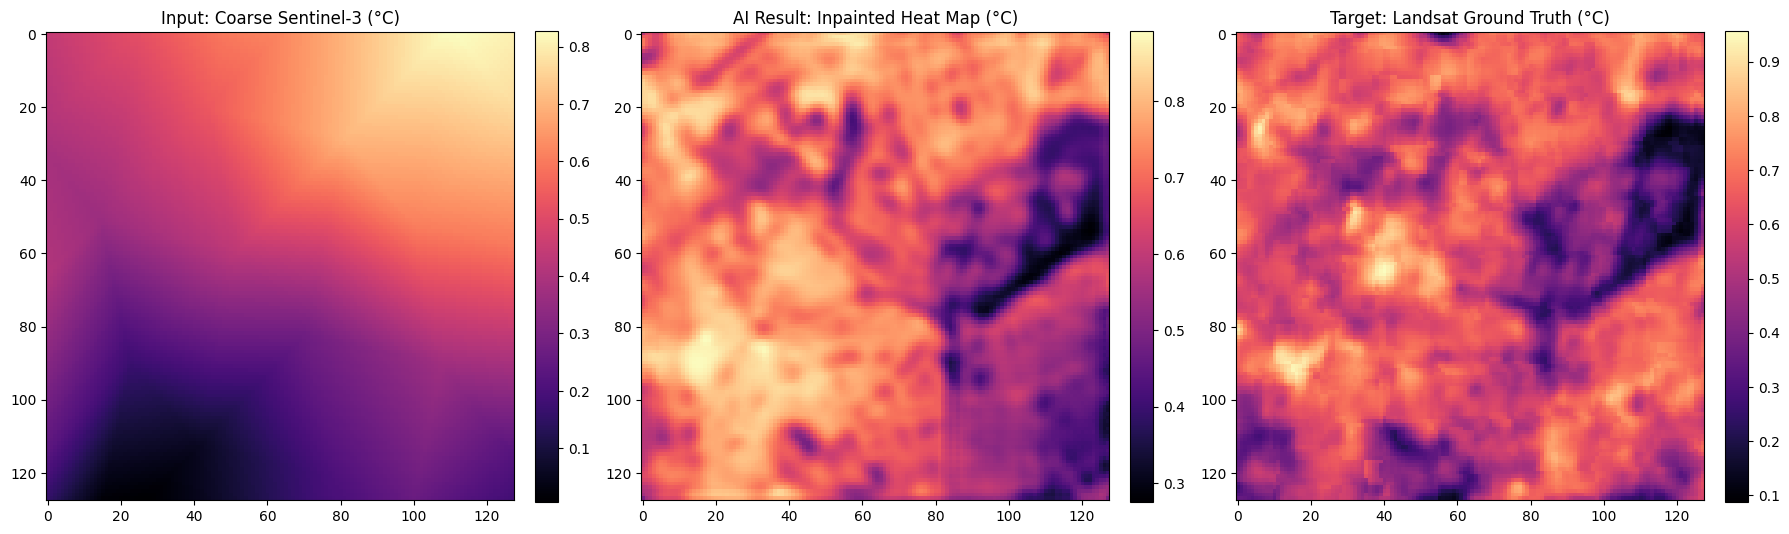

In [26]:
import matplotlib.pyplot as plt

# 1. Get a test sample
global_model.eval()
with torch.no_grad():
    inputs, targets = next(iter(test_loader))
    inputs, targets = inputs.to(device), targets.to(device)
    prediction = global_model(inputs)

# 2. Helper to convert tensors to Celsius
def denorm(x):
    return (x.cpu().numpy() * TRUE_RANGE) + TRUE_MIN

# 3. Plot
idx = 0
plt.figure(figsize=(18, 6))

# Panel 1: Input
plt.subplot(1, 3, 1)
im1 = plt.imshow(denorm(inputs[idx, 0]), cmap='magma')
plt.title("Input: Coarse Sentinel-3 (°C)")
plt.colorbar(im1, fraction=0.046, pad=0.04)

# Panel 2: AI Result
plt.subplot(1, 3, 2)
im2 = plt.imshow(denorm(prediction[idx, 0]), cmap='magma')
plt.title("AI Result: Inpainted Heat Map (°C)")
plt.colorbar(im2, fraction=0.046, pad=0.04)

# Panel 3: Target
plt.subplot(1, 3, 3)
im3 = plt.imshow(denorm(targets[idx, 0]), cmap='magma')
plt.title("Target: Landsat Ground Truth (°C)")
plt.colorbar(im3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Could not load online boundaries.


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: Unsupported option: https
  return ogr_read(


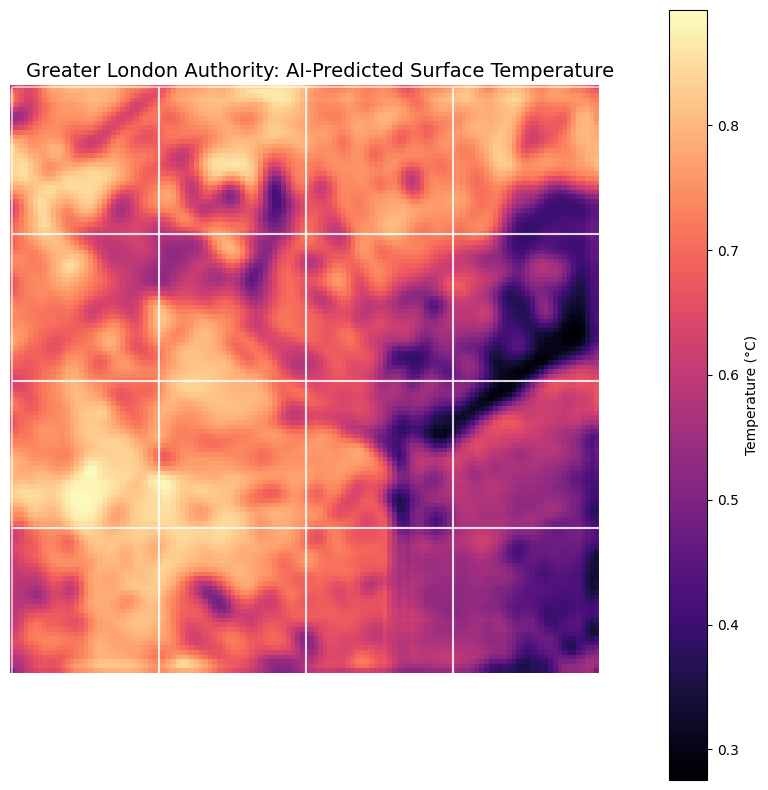

In [27]:
import geopandas as gpd

# 1. Load boundaries
try:
    url = "https://github.io"
    boroughs = gpd.read_file(url).to_crs(epsg=27700)
except:
    print("Could not load online boundaries.")

# 2. Display with AI Prediction
plt.figure(figsize=(10, 10))
im = plt.imshow(denorm(prediction[idx, 0]), cmap='magma', interpolation='nearest')

# Overlay white borough lines
boroughs.boundary.plot(ax=plt.gca(), color='white', linewidth=1.5, alpha=0.6)

plt.title("Greater London Authority: AI-Predicted Surface Temperature", fontsize=14)
plt.colorbar(im, label="Temperature (°C)")
plt.axis('off')
plt.show()
